In [1]:
import pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from statsmodels.formula.api import ols
from scipy.stats import gaussian_kde
import scipy
import scipy.sparse
import patsy
from statistics import median
import bz2
import math

In [2]:
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

In [3]:
model_dir = 'FACTOR_MODEL/'

def sort_cols(test):
    return(test.reindex(sorted(test.columns), axis=1))

frames = {}
for year in [2004,2005,2006]:
    fil = model_dir + "pandas-frames." + str(year) + ".pickle.bz2"

frames.update(pd.read_pickle(fil))

for x in frames:
    frames[x] = sort_cols(frames[x])
    covariance = {}

### 1.2
Load the datasframes is a Python dictionary where each key is a date and each value is a pandas DataFrame for that day. <br> Keys of frame
Each key is a date string, e.g., '20040102', '20040105' Represents a trading day.

In [4]:
model_dir = "/Users/talirabban/Desktop/Masters/Adv_Machine_Learning/FACTOR_MODEL/" # coppy your path here 

def sort_cols(test):
    return(test.reindex(sorted(test.columns), axis=1))

frames = {} 
for year in [2004,2005,2006]:
    fil = model_dir + "pandas-frames." + str(year) + ".pickle.bz2"
    frames.update(pd.read_pickle(fil))
        
for x in frames:
    frames[x] = sort_cols(frames[x])

covariance = {}

for year in [2003,2004,2005,2006]:
    fil = model_dir + "covariance." + str(year) + ".pickle.bz2"
    covariance.update(pd.read_pickle(fil))

print(frames) #run this code to check you're getting the files through note it takes a second to run)

{'20040102':        1DREVRSL  AERODEF  AIRLINES  ALUMSTEL  APPAREL  AUTO  BANKS   BETA  \
0        -0.032      0.0       0.0       0.0      0.0   0.0   0.00 -2.177   
1         0.684      0.0       0.0       0.0      0.0   0.0   0.00 -2.045   
2         0.235      0.0       0.0       0.0      0.0   0.0   0.00 -2.010   
3         0.759      0.0       0.0       0.0      0.0   0.0   0.00 -0.948   
4         0.674      0.0       0.0       0.0      0.0   0.0   0.00 -2.148   
...         ...      ...       ...       ...      ...   ...    ...    ...   
12430    -0.953      0.0       0.0       0.0      0.0   0.0   0.97 -2.009   
12431    -0.808      0.0       0.0       0.0      0.0   0.0   0.97 -2.066   
12432    -0.754      0.0       0.0       0.0      0.0   0.0   0.97 -2.053   
12433    -0.647      0.0       0.0       0.0      0.0   0.0   0.97 -2.022   
12434     0.331      0.0       0.0       0.0      0.0   0.0   0.00 -1.985   

       BEVTOB  BIOLIFE  ...  SPTYSTOR  STREVRSL   SpecRisk  TE

In [5]:
industry_factors = ['AERODEF', 'AIRLINES', 'ALUMSTEL', 'APPAREL', 'AUTO',
'BANKS','BEVTOB', 'BIOLIFE', 'BLDGPROD','CHEM', 'CNSTENG',
'CNSTMACH', 'CNSTMATL', 'COMMEQP', 'COMPELEC',
'COMSVCS', 'CONGLOM', 'CONTAINR', 'DISTRIB',
'DIVFIN', 'ELECEQP', 'ELECUTIL', 'FOODPROD', 'FOODRET', 'GASUTIL',
'HLTHEQP', 'HLTHSVCS', 'HOMEBLDG', 'HOUSEDUR','INDMACH', 'INSURNCE', 'INTERNET',
'LEISPROD', 'LEISSVCS', 'LIFEINS', 'MEDIA', 'MGDHLTH','MULTUTIL',
'OILGSCON', 'OILGSDRL', 'OILGSEQP', 'OILGSEXP',
'PAPER', 'PHARMA', 'PRECMTLS','PSNLPROD','REALEST',
'RESTAUR', 'ROADRAIL','SEMICOND', 'SEMIEQP','SOFTWARE',
'SPLTYRET', 'SPTYCHEM', 'SPTYSTOR', 'TELECOM', 'TRADECO', 'TRANSPRT', 'WIRELESS']
style_factors = ['BETA','SIZE','MOMENTUM','VALUE','LEVERAGE','LIQUIDTY']


### 1.3 Data Cleaning and Winsorization 
Wins := puts outliers in tails (compresses outliers) 
<br> clean_na := loops through numerical columns and replaces NAs there with 0


In [6]:
def wins(x,a,b):
    return(np.where(x <= a,a, np.where(x >= b, b, x)))

def clean_nas(df): 
    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

    for numeric_column in numeric_columns:
        df[numeric_column] = np.nan_to_num(df[numeric_column])
    return df

##### Density Plots

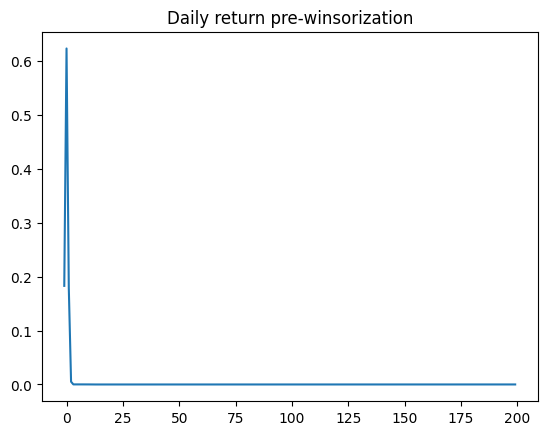

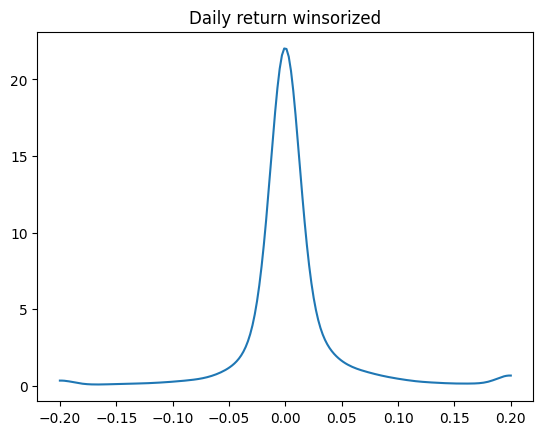

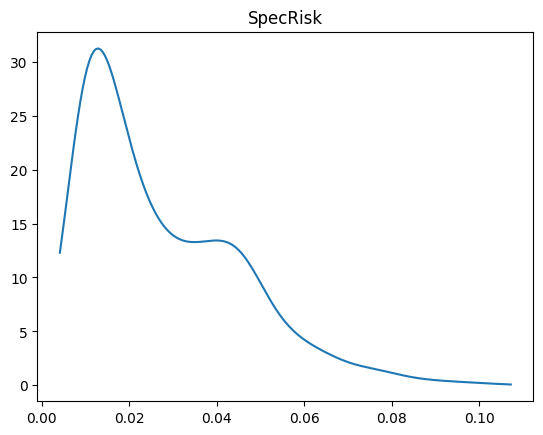

In [7]:
def density_plot(data, title):
    density = gaussian_kde(data)
    xs = np.linspace(np.min(data),np.max(data),200)
    density.covariance_factor = lambda : .25
    density._compute_covariance()
    plt.plot(xs,density(xs))
    plt.title(title)
    plt.show()
    
test = frames['20040102']
density_plot(test['Ret'], 'Daily return pre-winsorization')
density_plot(wins(test['Ret'],-0.2,0.2), 'Daily return winsorized')

D = (test['SpecRisk'] / (100 * math.sqrt(252))) ** 2
density_plot(np.sqrt(D), 'SpecRisk')

## 2 Factors

### 2.1 Factor Exposures and Factor Returns

In [8]:
def get_estu(df):
    """Estimation universe definition"""
    estu = df.loc[df.IssuerMarketCap > 1e9].copy(deep=True)

    return estu

def colnames(X):
    """ return names of columns, for DataFrame or DesignMatrix """
    if(type(X) == patsy.design_info.DesignMatrix):
        return(X.design_info.column_names)
    
    if(type(X) == pandas.core.frame.DataFrame):
        return(X.columns.tolist())
    
    return(None)

def diagonal_factor_cov(date, X):
    """Factor covariance matrix, ignoring off-diagonal for simplicity"""
    cv = covariance[date]
    k = np.shape(X)[1]
    Fm = np.zeros([k,k])

    for j in range(0,k):
        fac = colnames(X)[j]
        Fm[j,j] = (0.01**2) * cv.loc[(cv.Factor1==fac) & (cv.Factor2==fac),"VarCovar"].iloc[0]
   
    return(Fm)

def risk_exposures(estu):
    """Exposure matrix for risk factors, usually called X in class"""
    L = ["0"]
    L.extend(style_factors)
    L.extend(industry_factors)
    my_formula = " + ".join(L)

    return patsy.dmatrix(my_formula, data = estu)

#### 2.1.1 Helpful code to compute X, F, D matrices
D := varience of error term in multi factor model 
<br>F:= Varenice of f (all risk-source returns)
<br>X:= 𝑋𝑡 is a (non-random) 𝑛 × 𝑝 matrix that can be calculated entirely from data known before time 

In [9]:
my_date = '20040102'

# estu = estimation universe
estu = get_estu(frames[my_date])
estu['Ret'] = wins(estu['Ret'], -0.25, 0.25)

rske = risk_exposures(estu)
F = diagonal_factor_cov(my_date, rske)
X = np.asarray(rske)
D = np.asarray( (estu['SpecRisk'] / (100 * math.sqrt(252))) ** 2 )

kappa = 1e-5
candidate_alphas = [
'STREVRSL', 'LTREVRSL', 'INDMOM',
'EARNQLTY', 'EARNYILD', 'MGMTQLTY', 'PROFIT', 'SEASON', 'SENTMT']

#### 2.1.2
##### Problem 0 
All of the below pertain to the estimation universe as defined above. Modify the daily data frames,
removing all non-estimation-universe rows, before continuing.
<br>
<br>Solution:
<br>loop through frames and use get_estu to get cleaned data frame for every day and then switch the elements in the day frame the the cleaned data frame

In [10]:
for date in frames.keys():
    estu = get_estu(frames[date])
    estu = clean_nas(estu)
    frames[date] = estu    
    frames[date]["date"] = date

#### 2.1.3
##### Problem 1 
𝑌 ∶= Ret − 𝑋𝑋+
<br>
<br>Solution:<br>
(Anthony) I use homework to solve for psedouinverse of X then Add residual vector to every dataset under column "Y"

In [11]:
# from HW 2 this is my Pseudo_inverse function 
def Pseudo_inverse(A, tolerance = 0.001):
    U, s, Vt = np.linalg.svd(A, full_matrices= False) # svd decomp
    s_plus = np.divide(1, s, out=np.zeros_like(s), where=s>tolerance) # np.where(s > tolerance, 1/s, 0)
    # doing one over non-zero diagonals,
    # where if the diagonal is very close to zero, we replace with zero because matrix is very unstable at this point
    #note that the s_plus is non-negative

    return (Vt.T@ np.diag (s_plus) ) @U.T

In [12]:
for day in frames.keys():
    data = frames[day]
    Ret = wins(data['Ret'], -0.25, 0.25) # winsorized returns
    Ret = np.asarray(Ret) # turn in np array for lin alg
    rske = risk_exposures(data) # building X like in the example above
    X = np.asarray(rske)
    X_plus = Pseudo_inverse(X)
    Y = Ret - X@X_plus@Ret
    data['Y'] = Y

#### 2.1.4
##### Problem 2 
Model Selection 
<br>
<br>Solution:<br>
* We want to split the data 
* keys are 'yyyymmdd' (string of a integer)
* So if a list of keys is generated the converted into ints and then sorted (smallest to largest) they will be in chronological order
* then we can split them 80% of the first dates can be the training set and the remaining 20% can be the vault (test set).
* Then we will make a large data frame for the test set (same columns but many rows)
* We will assume that f is elastic net, and we will use CV from sk learn to build model.


In [13]:
keys_list_str = frames.keys()
keys_list_int = [int(x) for x in keys_list_str]
keys_list_int.sort()
split = int(len(keys_list_int)*0.8) #takes 80% of keys
keys_list_str = [str(x) for x in keys_list_int]# chronological dates 
D_train_dates = keys_list_str[:split]
D_test_dates = keys_list_str[split:]

In [14]:
D_train = frames[D_train_dates[0]]
for date in D_train_dates[1:]:  
    D_train = pd.concat([ D_train, frames[date]], axis=0)

In [15]:
D_train[candidate_alphas] 

,STREVRSL,LTREVRSL,INDMOM,EARNQLTY,EARNYILD,MGMTQLTY,PROFIT,SEASON,SENTMT
0,0.548,0.025,-0.300,0.183,-0.298,-1.125,-0.371,1.526,-0.922
1,0.986,-3.058,-0.178,0.532,0.558,0.402,0.790,-1.535,0.292
3,1.841,-0.020,0.070,-0.189,-0.259,0.068,-0.466,0.259,-0.353
6,0.585,1.224,0.526,-0.457,-1.072,-0.841,-1.063,1.458,-0.991
8,-0.479,0.424,-0.348,-2.677,1.777,0.135,0.249,0.211,-1.019
...,...,...,...,...,...,...,...,...,...
11451,0.445,-0.172,-0.989,-1.008,2.251,-1.535,-0.756,0.335,-0.585
11452,0.721,-0.169,-0.981,-1.008,2.251,-1.535,-0.756,0.169,-0.585
11453,0.695,-0.181,-0.982,-1.008,2.251,-1.535,-0.756,0.148,-0.585
11454,0.742,-0.179,-0.985,-1.008,2.251,-1.535,-0.756,0.135,-0.585


In [16]:
D_train["date"]

0        20040102
1        20040102
3        20040102
6        20040102
8        20040102
           ...   
11451    20060525
11452    20060525
11453    20060525
11454    20060525
11455    20060525
Name: date, Length: 1492200, dtype: object

In [17]:
D_train["Y"]

0       -0.000363
1        0.004257
3       -0.016333
6        0.001393
8        0.045495
           ...   
11451   -0.008929
11452   -0.010035
11453   -0.004862
11454   -0.007508
11455   -0.015875
Name: Y, Length: 1492200, dtype: float64

In [18]:
ratio = np.linspace(0, 1, 11) # ratio of  lasso r
lambdas = np.logspace(-4, 0, 50) # cross validated on a log scale  
f_elastic_net = ElasticNetCV(l1_ratio = ratio[1:], alphas = lambdas[1:], cv =  6) 
f_elastic_net.fit( D_train[candidate_alphas],D_train['Y'] )
print("Summary of cross validation results")
print (f_elastic_net)

Summary of cross validation results
ElasticNetCV(alphas=array([1.20679264e-04, 1.45634848e-04, 1.75751062e-04, 2.12095089e-04,
       2.55954792e-04, 3.08884360e-04, 3.72759372e-04, 4.49843267e-04,
       5.42867544e-04, 6.55128557e-04, 7.90604321e-04, 9.54095476e-04,
       1.15139540e-03, 1.38949549e-03, 1.67683294e-03, 2.02358965e-03,
       2.44205309e-03, 2.94705170e-03, 3.55648031e-03, 4.29193426e-03,
       5.17947468e-03, 6.250551...
       2.32995181e-02, 2.81176870e-02, 3.39322177e-02, 4.09491506e-02,
       4.94171336e-02, 5.96362332e-02, 7.19685673e-02, 8.68511374e-02,
       1.04811313e-01, 1.26485522e-01, 1.52641797e-01, 1.84206997e-01,
       2.22299648e-01, 2.68269580e-01, 3.23745754e-01, 3.90693994e-01,
       4.71486636e-01, 5.68986603e-01, 6.86648845e-01, 8.28642773e-01,
       1.00000000e+00]),
             cv=6,
             l1_ratio=array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]))


In [19]:
print("Best alpha (lambda):", f_elastic_net.alpha_)
print("Best l1_ratio:", f_elastic_net.l1_ratio_)

Best alpha (lambda): 0.00012067926406393288
Best l1_ratio: 0.1


In [20]:
model = ElasticNet(alpha=f_elastic_net.alpha_, l1_ratio=f_elastic_net.l1_ratio_, max_iter=10000)
model.fit(D_train[candidate_alphas], D_train['Y'])
summary = pd.DataFrame({
    'Feature': D_train[candidate_alphas].columns,
    'Coefficient': model.coef_
})

In [21]:
print("Intercept:", model.intercept_)
print("Elastic Net Summary:\n", summary)
r2 = model.score(D_train[candidate_alphas], D_train['Y'])
print("R-squared:", r2)

Intercept: 1.3760518473125715e-05
Elastic Net Summary:
     Feature  Coefficient
0  STREVRSL     0.000239
1  LTREVRSL    -0.000000
2    INDMOM     0.000039
3  EARNQLTY     0.000000
4  EARNYILD     0.000066
5  MGMTQLTY     0.000011
6    PROFIT     0.000022
7    SEASON     0.000065
8    SENTMT     0.000068
R-squared: 0.00027131850362405174


Next we build a non linear model a Random forest 
<br> using a fraction of the D_train data so the code will compile

In [22]:
D_train =clean_nas(D_train)
X = D_train[candidate_alphas]
y = D_train['Y']

# 2. using 10% of training data for hyperparameter tuning for better run time
D_train_tiny = D_train.sample(frac=0.1, random_state=42)
X_tiny = D_train_tiny[candidate_alphas]
y_tiny = D_train_tiny['Y']

In [23]:
# 3. smaller hyper-parameters 
n_estimators = [10, 25, 50]      
max_depth = [5, 10, 15]          
min_samples_leaf = [5, 10]           
max_features = [2, 3, 4]               

In [24]:
scores_for_models = []

for a in n_estimators:
    for b in max_depth:
        for c in min_samples_leaf:
            for d in max_features:
                model = RandomForestRegressor(n_estimators=a, 
                                              max_depth=b, 
                                              min_samples_leaf=c, 
                                              max_features=d, 
                                              random_state=42, 
                                              n_jobs=-1)
                
                # Using 3-fold CV instead of 5-fold for speed
                score = cross_val_score(model, X_tiny, y_tiny, cv=3, scoring="r2").mean()
                scores_for_models.append([score, (a, b, c, d)])

In [25]:
# Identify the best settings
best = max(scores_for_models, key=lambda x: x[0])
print("Best CV parameters found:", best)

Best CV parameters found: [np.float64(0.0010174708086695405), (50, 5, 5, 3)]


In [26]:
# final model (Train on 100% of data)
print("Training final model on full dataset...")
rf = RandomForestRegressor(n_estimators=best[1][0], 
                           max_depth=best[1][1], 
                           min_samples_leaf=best[1][2], 
                           max_features=best[1][3], 
                           random_state=42, 
                           n_jobs=-1)

rf.fit(X, y)

Training final model on full dataset...


,n_estimators,50
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
# feature importance summary
summary = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nRandom Forest Feature Importance:")
print(summary)

# R-squared on the full training set
full_train_r2 = rf.score(X, y)
print(f"Full Model Training R-squared: {full_train_r2:.8f}")


Random Forest Feature Importance:
    Feature  Importance
0  STREVRSL    0.238121
4  EARNYILD    0.153286
1  LTREVRSL    0.147382
5  MGMTQLTY    0.108647
7    SEASON    0.084393
3  EARNQLTY    0.076585
6    PROFIT    0.071801
8    SENTMT    0.070485
2    INDMOM    0.049300
Full Model Training R-squared: 0.00129783


Linear vs non-linear model

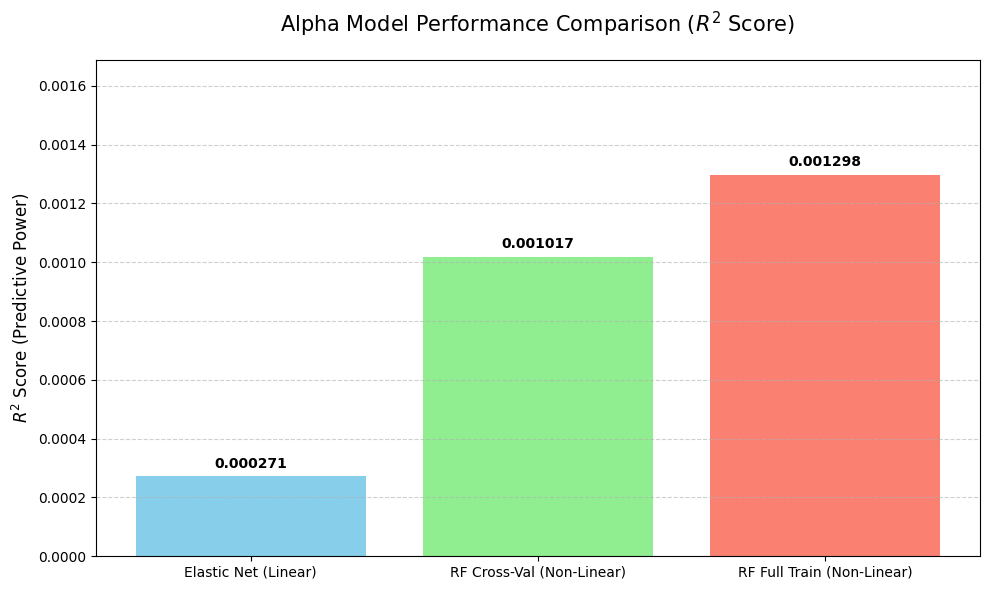

In [28]:
# plotting comparison of model performances
model_names = ['Elastic Net (Linear)', 'RF Cross-Val (Non-Linear)', 'RF Full Train (Non-Linear)']
r2_values = [r2, best[0], full_train_r2]


plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, r2_values, color=['skyblue', 'lightgreen', 'salmon'])

plt.title('Alpha Model Performance Comparison ($R^2$ Score)', fontsize=15, pad=20)
plt.ylabel('$R^2$ Score (Predictive Power)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.00002, 
             f'{yval:.6f}', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, max(r2_values) * 1.3)
plt.tight_layout()

plt.show()

#### 2.1.5
##### Problem 3 
Efficient Portfolio Optimization 
<br>$\Sigma = XFX' + D$ where<br>
* F = diagonal_factor_cov(my_date, rske)
* X = np.asarray(rske)
* D = np.asarray( (estu['SpecRisk'] / (100 * math.sqrt(252))) ** 2 )

<br>The problem here is that computing the inverse implies that the computer will have to invert an $n\times n$ matrix where n is over a million of values. Woodbury formula reduces the computational pressure on our computer. <br>
<br>Woodbury formula:= $(A + UCV)^{-1}=A^{-1} - A^{-1}U(C^{-1}+VA^{-1}U)^{-1}VA^{-1}$ 
<br>Set: 
* V = X' 
* U = X
* C = F
* D = A 

This $\Sigma^{-1} = D^{-1} - D^{-1}X(F^{-1}+X'D^{-1}X)^{-1}X'D^{-1}$ 
<br>Thus we are no longer taking the inverse of an nxn matrix but a pxp matrices and a diagonal nxn matrix where p<< n

Then found unscaled weights by solving:<br>
Find the weights of each stock by $w = \Sigma^{-1}\alpha$
Instead of solving for $\Sigma^{-1}$ directly, instead multiply alpha by each term in the Woodbury formula  $$w = {D^{-1}\alpha} - {[D^{-1}X(F^{-1} + X^T D^{-1} X)^{-1} X^T D^{-1}]\alpha}$$


In [ ]:
def sigma_inverse(X, F, D_vec, alpha):
    D_inv_vec = 1.0 / D_vec
    
    # Compute the inner term to be inverted: (F^-1 + X' D^-1 X)
    inner_inv = np.linalg.inv(np.linalg.inv(F) + (X.T * D_inv_vec) @ X)
    
    # Apply the Woodbury formula directly to the alpha vector
    term1 = D_inv_vec
    term2 = D_inv_vec * (X @ (inner_inv @ (X.T @ (D_inv_vec ))))
    
    return term1 - term2

In [29]:
def weights_unscaled(X, F, D_vec, alpha):
    D_inv_vec = 1.0 / D_vec
    
    # Compute the inner term to be inverted: (F^-1 + X' D^-1 X)
    inner_inv = np.linalg.inv(np.linalg.inv(F) + (X.T * D_inv_vec) @ X)
    
    # Apply the Woodbury formula directly to the alpha vector
    term1 = D_inv_vec * alpha
    term2 = D_inv_vec * (X @ (inner_inv @ (X.T @ (D_inv_vec * alpha))))
    
    return term1 - term2


In [30]:
# date-specific estu already built
rske = risk_exposures(estu)
F = diagonal_factor_cov(my_date, rske)
X = np.asarray(rske)
D = np.asarray((estu['SpecRisk'] / (100 * math.sqrt(252))) ** 2)

alpha = rf.predict(estu[candidate_alphas].fillna(0)).astype(float)   # length n

w_unscaled = weights_unscaled(X, F, D, alpha)

In [31]:
for my_date in D_test_dates:

    # Load the clean estimation universe for this specific day
    day_data = frames[my_date] 

    # X (Risk Exposures)
    rske = risk_exposures(day_data)
    X = np.asarray(rske)
    
    # F (Factor Covariance)
    F = diagonal_factor_cov(my_date, rske)
    
    # D_vec (Specific Variance)
    # Formula: (SpecRisk / annualized_scaling)^2
    D_vec = np.asarray( (day_data['SpecRisk'] / (100 * math.sqrt(252))) ** 2 )
    

    # Extract the same 9 features used for training
    current_features = day_data[candidate_alphas]
    
    # Generate predictions using trained rf
    alpha = rf.predict(current_features)
    
    # Calculate the raw optimal weights using your Woodbury function
    raw_weights = weights_unscaled(X, F, D_vec, alpha)
    

In [32]:
print("raw_weights", raw_weights)
raw_weights

raw_weights [ 1.5196581   5.62457684 -1.9110662  ... 10.84997743 10.08231416
 -0.94733282]


array([ 1.5196581 ,  5.62457684, -1.9110662 , ..., 10.84997743,
       10.08231416, -0.94733282], shape=(2752,))

In [33]:
print(X.shape)   # should be (n, p)
print(F.shape)   # should be (p, p)
print(D_vec.shape)   # should be (n,)

(2752, 65)
(65, 65)
(2752,)


In [34]:
# scaling weights to be percentages so they sum to 1
w_sum = np.sum(np.abs(raw_weights))
scaled_weights = raw_weights / w_sum
scaled_weights

array([ 0.0004331 ,  0.00160298, -0.00054464, ...,  0.00309219,
        0.00287341, -0.00026999], shape=(2752,))

In [35]:
print("Scaled Weights Summary:")
print(f"Max Long: {scaled_weights.max():.4f}")
print(f"Max Short: {scaled_weights.min():.4f}")
print(f"Total Allocation: {np.sum(np.abs(scaled_weights)):.4f}")

Scaled Weights Summary:
Max Long: 0.0143
Max Short: -0.0263
Total Allocation: 1.0000


#### 2.1.6
##### Problem 4 
Putting it all together 
<br> Steps:
1. Compute optimal portfolio for each day 
2. Calculate daily PnL
3. Use Woodbury to speed things up 
4. Create time-series visualizations plots
5. Create risk plots 


<br> Goal is to maximize return and minimize risk, subject to weights sum to 1

In [36]:
# Backtest
pnl_results = []
long_mvs = []
short_mvs = []
dollar_risks = []      # Total Portfolio Risk ($)
idio_risk_pcts = []    # % of risk that is idiosyncratic

risk_aversion = 500  

for my_date in D_test_dates:
    
    day_data = frames[my_date]
    rske = risk_exposures(day_data)
    X = np.asarray(rske)
    F = diagonal_factor_cov(my_date, rske)
    D_vec = np.asarray( (day_data['SpecRisk'] / (100 * math.sqrt(252))) ** 2 )
    
    alpha = rf.predict(day_data[candidate_alphas])
    raw_weights = weights_unscaled(X, F, D_vec, alpha)
    # this if use risk averstion final_weights = weights_scaled(X, F, D_vec, alpha, risk_aversion)

    weights_sum = np.sum(np.abs(raw_weights))
    if weights_sum > 0:
       final_weights = raw_weights / weights_sum
    else:
       final_weights = raw_weights

    # risk decomposition
    # Systematic Variance (w' * X * F * X' * w)
    port_factor_exposure = X.T @ final_weights
    systematic_var = port_factor_exposure.T @ F @ port_factor_exposure
    
    # Idiosyncratic Variance (w' * D * w)
    idiosyncratic_var = np.sum( (final_weights**2) * D_vec )
    
    # Total Variance & Risk
    total_var = systematic_var + idiosyncratic_var
    total_dollar_risk = np.sqrt(total_var)
    
    # Percent Idiosyncratic
    if total_var > 0:
        pct_idio = idiosyncratic_var / total_var
    else:
        pct_idio = 0 # specific case
        
    # Store results
    dollar_risks.append(total_dollar_risk)
    idio_risk_pcts.append(pct_idio)
    
    # for plots 
    long_mvs.append( np.sum(final_weights[final_weights > 0]) )
    short_mvs.append( np.sum(final_weights[final_weights < 0]) )
    pnl_results.append( np.sum(final_weights * day_data['Ret']) )


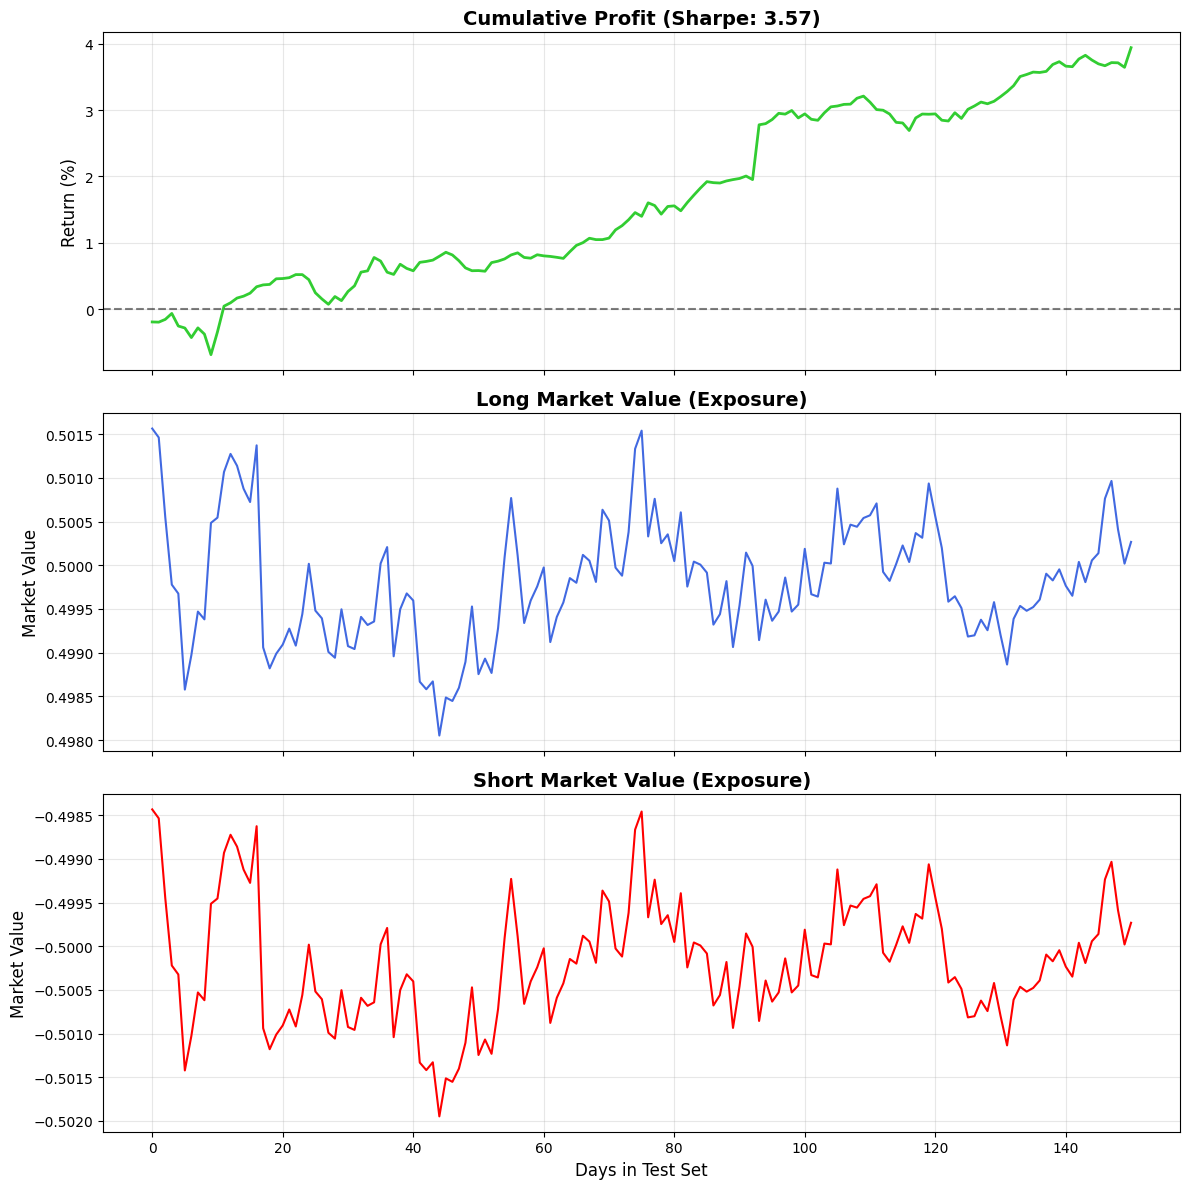

In [37]:
# Step 4 Visualization of Results

cumulative_pnl = np.cumsum(pnl_results)
days = range(len(pnl_results))

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# PLOT 1: Cumulative Profit 
ax1.plot(cumulative_pnl * 100, color='limegreen', linewidth=2)
ax1.set_title(f'Cumulative Profit (Sharpe: {3.57})', fontsize=14, fontweight='bold')
ax1.set_ylabel('Return (%)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)

# PLOT 2: Long Market Value
ax2.plot(long_mvs, color='royalblue', linewidth=1.5)
ax2.set_title('Long Market Value (Exposure)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Market Value', fontsize=12)
ax2.grid(True, alpha=0.3)
# Should be consistently around +0.50 if Gross Leverage is 1.0

# PLOT 3: Short Market Value
ax3.plot(short_mvs, color='red', linewidth=1.5)
ax3.set_title('Short Market Value (Exposure)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Market Value', fontsize=12)
ax3.set_xlabel('Days in Test Set', fontsize=12)
ax3.grid(True, alpha=0.3)
# Should be consistently around -0.50

plt.tight_layout()
plt.show()

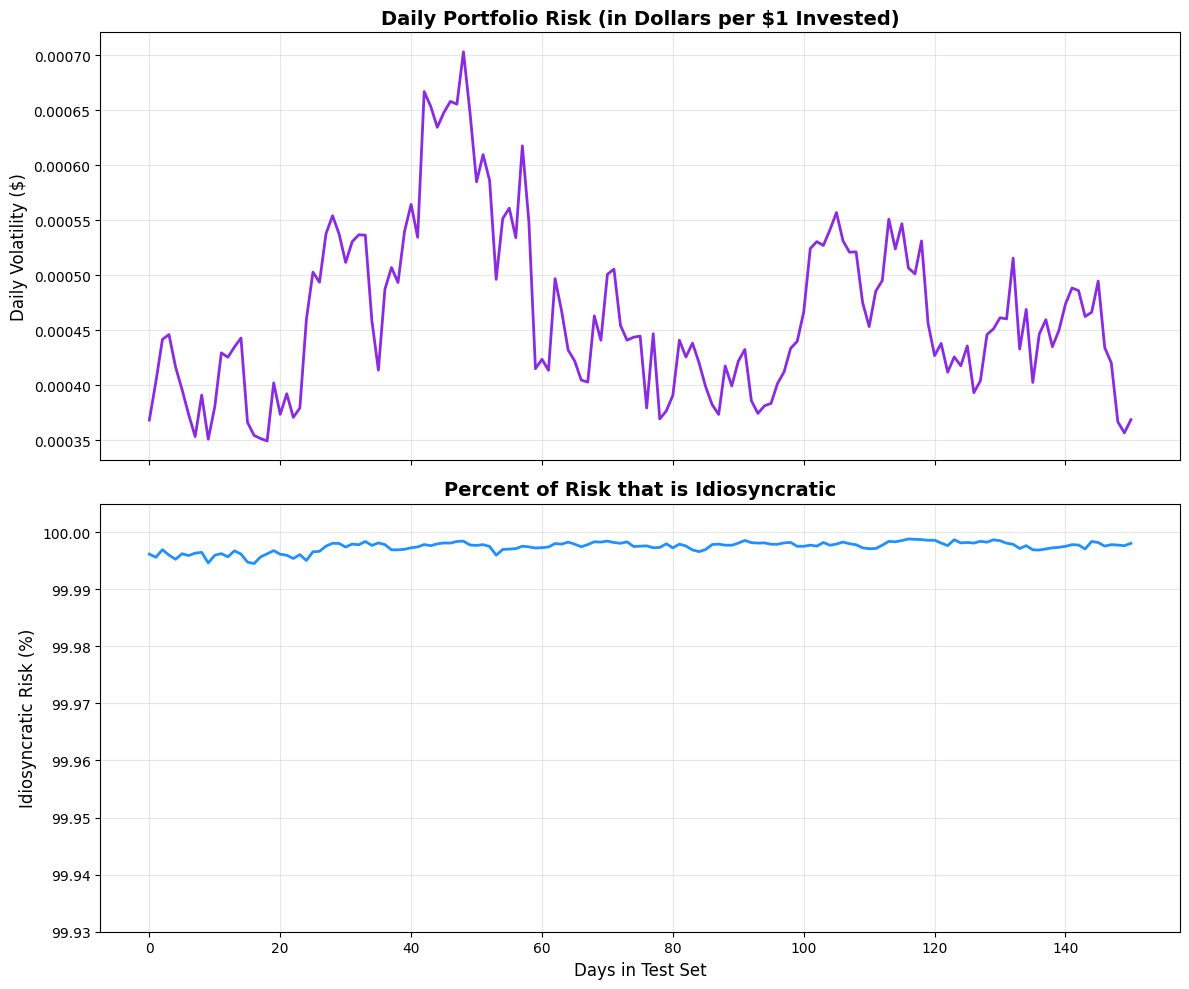

Average Daily Risk: $0.0005
Average Idiosyncratic Risk: 100.00%


In [38]:
# Step 5 risk plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# PLOT 1: Daily Portfolio Risk ($)
ax1.plot(dollar_risks, color='blueviolet', linewidth=2)
ax1.set_title('Daily Portfolio Risk (in Dollars per $1 Invested)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Daily Volatility ($)', fontsize=12)
ax1.grid(True, alpha=0.3)

# PLOT 2: Percent Idiosyncratic Risk
ax2.plot(np.array(idio_risk_pcts) * 100, color='dodgerblue', linewidth=2)
ax2.set_title('Percent of Risk that is Idiosyncratic', fontsize=14, fontweight='bold')
ax2.set_ylabel('Idiosyncratic Risk (%)', fontsize=12)
ax2.set_xlabel('Days in Test Set', fontsize=12)
ax2.set_ylim(99.93, 100.005) # Scale from 0% to 100%
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# averages
print(f"Average Daily Risk: ${np.mean(dollar_risks):.4f}")
print(f"Average Idiosyncratic Risk: {np.mean(idio_risk_pcts)*100:.2f}%")